# CMNIST pretrained-generator correction demo

This notebook is intentionally a **viewer**, not a training script. The heavy GPU experiment is run by:

```bash
python examples/cmnist/run.py --device cuda --output examples/cmnist/results/default
```

The runner writes a compact result bundle, and this notebook loads that bundle for quick comparison. Re-execute the notebook after each backend run so the displayed outputs match the saved checkpoints and metrics.

In [1]:
from pathlib import Path
import sys, json
import torch
import matplotlib.pyplot as plt

# Find the repo root whether Jupyter was launched from the repo root or this folder.
_here = Path.cwd().resolve()
_candidates = [_here, *_here.parents]
REPO_ROOT = next(p for p in _candidates if (p / "src" / "deconfoundingfm").exists())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from deconfoundingfm.experimental.cmnist import load_result_bundle

RESULT_DIR = REPO_ROOT / "examples" / "cmnist" / "results" / "default"
bundle = load_result_bundle(RESULT_DIR)
metrics = bundle["metrics"]
config = bundle["config"]
manifest = bundle["manifest"]
convergence = bundle["convergence"]
samples = bundle["samples"]

print("Result directory:", RESULT_DIR)
print("Preview only:", bool(metrics.get("preview_only", False)))
print(json.dumps(config, indent=2))

Result directory: /nfs/ghome/live/danceh/DeconfoundingFlowMatching/examples/cmnist/results/default
Preview only: False
{
  "output": "/nfs/ghome/live/danceh/DeconfoundingFlowMatching/examples/cmnist/results/default",
  "device": "cuda",
  "seed": 0,
  "bw_shapes": 10000,
  "colors_per_shape": 2,
  "confounding_w": 5.0,
  "propensity_trees": 1000,
  "propensity_cv_folds": 5,
  "nuisance_steps": 20000,
  "nuisance_lr": 0.0001,
  "target_steps": 20000,
  "target_lr": 0.0001,
  "batch_size": 128,
  "unet_c": 32,
  "ode_steps": 50,
  "plugin_reservoir": 2,
  "plugin_batch": 1,
  "base_noise_std": 0.0,
  "checkpoints": [
    250,
    500,
    1000,
    2000,
    5000,
    10000,
    15000,
    20000
  ],
  "eval_n": 512,
  "checkpoint_eval_n": 128,
  "sw2_projections": 256,
  "sample_chunk": 64,
  "smoke": false,
  "observational_n": 20000,
  "digits": [
    1,
    6
  ],
  "tau": 0.08,
  "k": 10.0,
  "fg_alpha": 0.0,
  "ubyte_source": "packaged original t10k-images.idx3-ubyte / t10k-labels.

## Exact CMNIST source and causal target

The repo bundles the same `t10k-images.idx3-ubyte` / `t10k-labels.idx1-ubyte` files and recoloring map used in the original experiments. The biased source generator samples fresh $P(Y\mid A=a)$ images from this exact DGP.

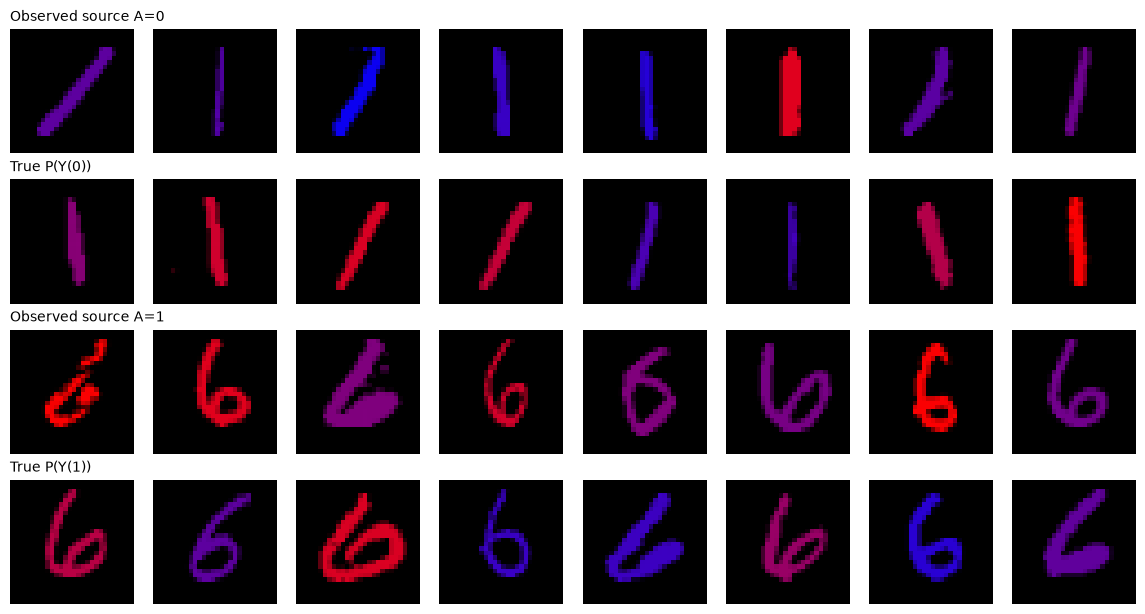

In [2]:
def show_rows(groups, n=8):
    n = min(int(n), min(len(imgs) for _, imgs in groups))
    rows = len(groups)
    fig, axes = plt.subplots(rows, n, figsize=(1.45*n, 1.55*rows))
    if rows == 1:
        axes = [axes]
    if n == 1:
        axes = [[ax] for ax in axes]
    for r, (title, imgs) in enumerate(groups):
        for c in range(n):
            ax = axes[r][c]
            ax.imshow(imgs[c].permute(1,2,0).clamp(0,1).cpu())
            ax.axis("off")
            if c == 0:
                ax.set_title(title, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()

show_rows([
    ("Observed source A=0", samples["observed_a0"]),
    ("True P(Y(0))", samples["true_a0"]),
    ("Observed source A=1", samples["observed_a1"]),
    ("True P(Y(1))", samples["true_a1"]),
])

## Saved backend results

In [3]:
if metrics.get("preview_only", False):
    print("The committed bundle is a DGP preview only. Run examples/cmnist/run.py on GPU to populate model results.")
    print("Source-vs-target SW2 preview:", metrics["source_sw2"])
else:
    rows = [
        ("Observed source", metrics["source_sw2"]),
        ("DeconfoundingFM", metrics["decfm_sw2"]),
        ("OT-DeconfoundingFM", metrics["ot_sw2"]),
    ]
    for name, value in rows:
        print(f"{name:24s} SW2 = {value:.4f}")

Observed source          SW2 = 0.0332
DeconfoundingFM          SW2 = 0.0257
OT-DeconfoundingFM       SW2 = 0.0164


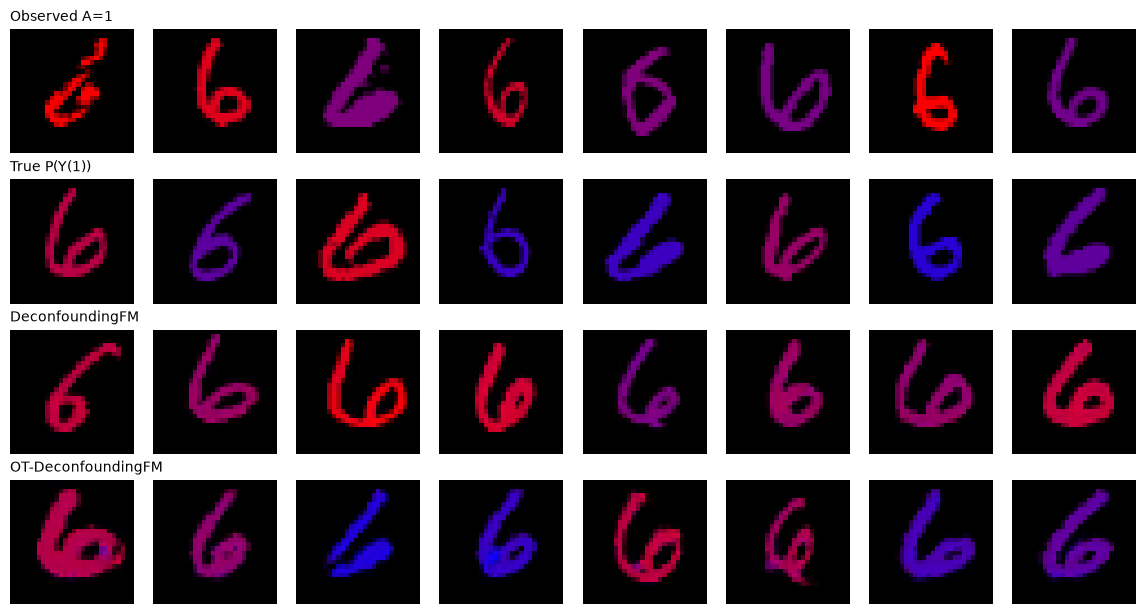

In [4]:
if not metrics.get("preview_only", False):
    show_rows([
        ("Observed A=1", samples["observed_a1"]),
        ("True P(Y(1))", samples["true_a1"]),
        ("DeconfoundingFM", samples["decfm_a1"]),
        ("OT-DeconfoundingFM", samples["ot_a1"]),
    ])

## SW2 convergence

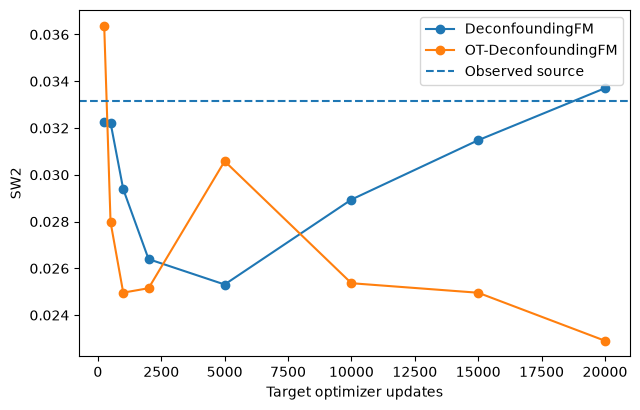

In [5]:
if convergence["steps"]:
    plt.figure(figsize=(6.5,4.2))
    plt.plot(convergence["steps"], convergence["decfm"], marker="o", label="DeconfoundingFM")
    plt.plot(convergence["steps"], convergence["ot"], marker="o", label="OT-DeconfoundingFM")
    plt.axhline(metrics["source_sw2"], linestyle="--", label="Observed source")
    plt.xlabel("Target optimizer updates")
    plt.ylabel("SW2")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No trained convergence results in the preview bundle. Run the GPU backend first.")

## Reproducing the full run

The backend uses a fixed labeled observational dataset with **10,000 grayscale shape draws × 2 independent color draws = 20,000 observations**. Both the conditional outcome nuisance and the independent/OT correction flows draw fresh base samples from the exact biased generator on every optimization update. The propensity is estimated from the fixed $(X,A)$ data; the learner never receives the true propensity.